# 00 - Panorama histórico: del texto a los embeddings

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque1/00-panorama.ipynb)

> **Duración orientativa:** 45-60 min
>
> **Propósito:** ofrecer un mapa histórico y conceptual antes de entrar
> en la arquitectura de los modelos actuales.
>
> Esta página no sustituye ninguno de los contenidos del Bloque 1. Sirve
> para entender por qué aparecen los embeddings, qué problema resuelven
> y cómo se relacionan con los LLMs y los sistemas RAG.

> **Idea guía**
>
> Un sistema de IA no puede trabajar directamente con el significado
> humano de una frase. Necesita una representación que pueda comparar,
> transformar y utilizar para predecir. La historia que conduce a los
> modelos actuales es, en buena medida, la historia de mejorar esa
> representación.

## Objetivos de esta introducción

Al terminar este panorama deberías poder:

- explicar por qué una palabra, una frase o un documento necesitan
  convertirse en números;
- distinguir representaciones dispersas de representaciones densas;
- diferenciar un embedding de entrada, un estado oculto contextual y un
  embedding de frase;
- describir qué aportan word2vec, BERT, SBERT y E5 en la evolución de
  las representaciones;
- relacionar embeddings, búsqueda vectorial y RAG con la generación de
  texto de un LLM;
- entender que la historia de las representaciones y la historia de la
  generación son dos líneas relacionadas, pero no idénticas.

## El problema: el texto no es todavía una geometría

Para una persona, estas frases están claramente relacionadas:

``` text
El gato duerme sobre la alfombra.
Un felino descansa en la moqueta.
La bolsa europea cerró al alza.
```

La primera y la segunda expresan una situación parecida aunque apenas
compartan palabras. La tercera pertenece a otro tema. Un sistema de
búsqueda basado exclusivamente en coincidencia literal puede tener
dificultades para distinguir estas relaciones.

El problema general puede formularse así:

> ¿Cómo convertimos objetos complejos, como palabras, frases, imágenes o
> filas tabulares, en puntos de un espacio donde la cercanía tenga un
> significado útil?

La respuesta ha ido cambiando con el tiempo. Primero se contaban
palabras. Después se aprendían vectores. Más tarde se incorporó el
contexto. Finalmente se aprendió a producir representaciones
directamente optimizadas para comparar frases, recuperar documentos o
alinear modalidades.

<figure id="fig-flujo-historico">
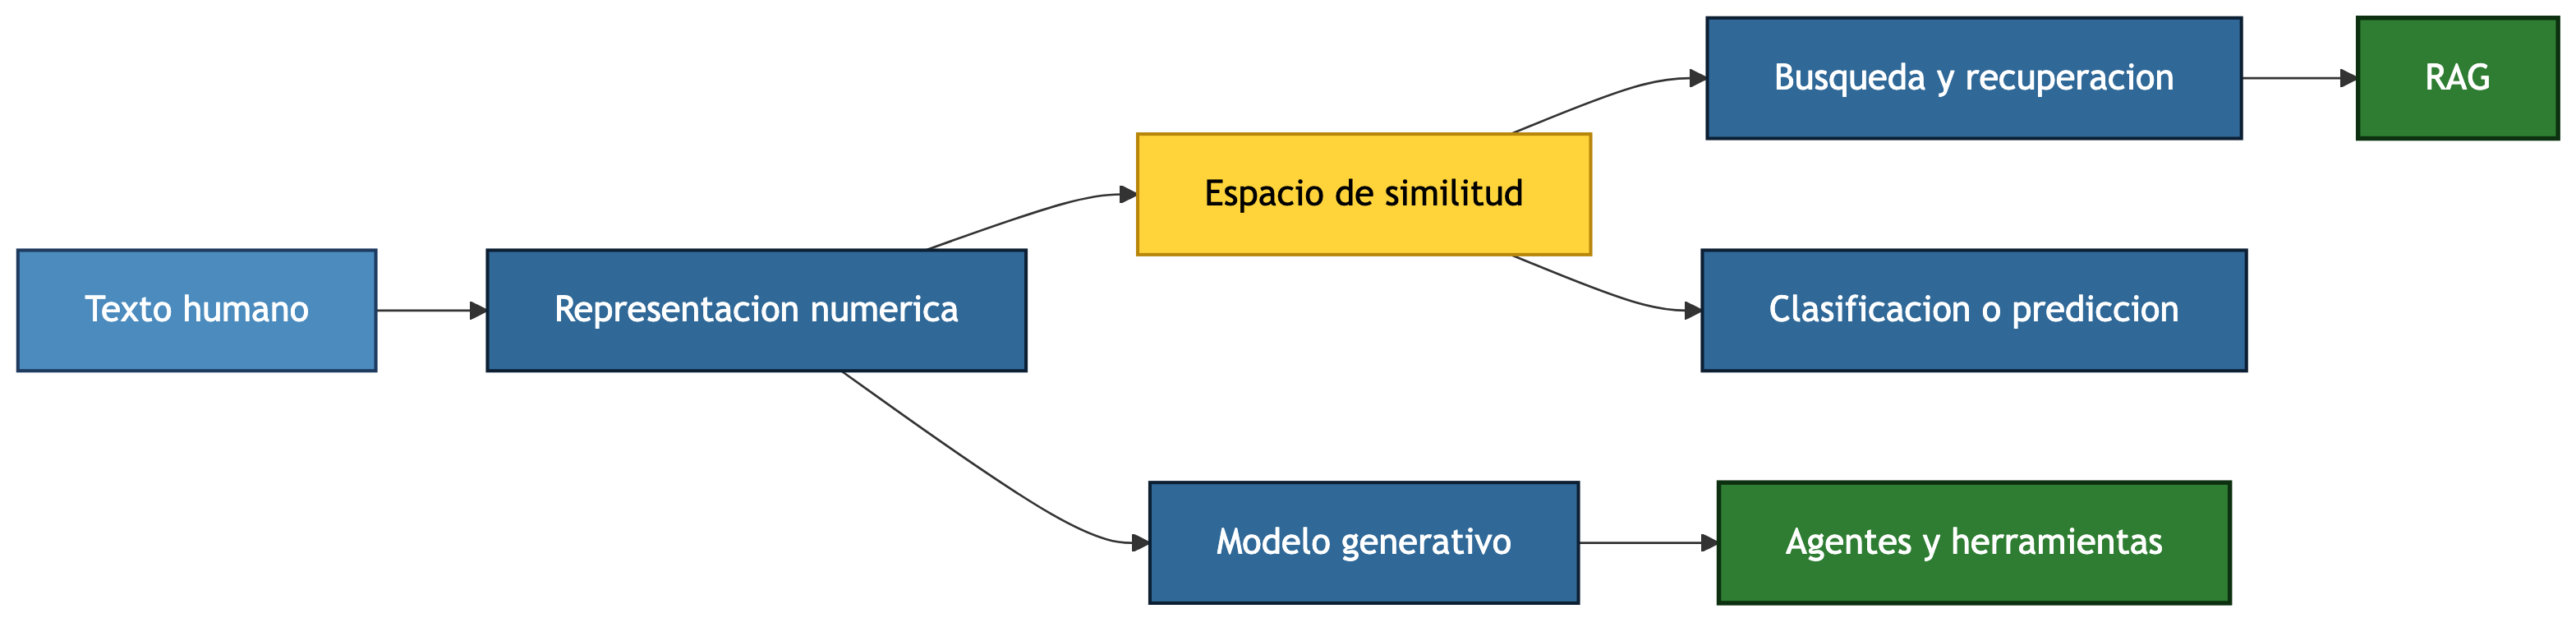
<figcaption>Figura 1</figcaption>
</figure>

<a href="#fig-flujo-historico" class="quarto-xref">Figura 1</a> resume
el hilo conductor del módulo: una representación numérica puede servir
para recuperar información o para alimentar un modelo que genera una
salida. Los embeddings son especialmente importantes en la primera rama,
aunque también aparecen dentro de los propios LLMs.

## Dos historias que se encuentran

La evolución de la IA generativa no es una única escalera. Hay dos
líneas históricas que terminan combinándose en los sistemas actuales.

### Línea A: representar significado

``` text
one-hot -> Bag of Words / TF-IDF -> word2vec y GloVe
        -> representaciones contextuales -> SBERT y E5
        -> vector DB -> recuperacion semantica -> RAG
```

Esta línea intenta que textos relacionados ocupen posiciones próximas en
un espacio vectorial. Su pregunta principal es: **¿qué objetos son
semánticamente parecidos o relevantes para una consulta?**

### Línea B: generar lenguaje

``` text
modelos simbolicos -> RNN / LSTM -> Transformer
                   -> preentrenamiento causal -> LLM
                   -> instrucciones -> herramientas -> agentes
```

Esta línea intenta modelar una distribución de probabilidad para
producir el siguiente token y, a partir de esa operación repetida,
generar texto. Su pregunta principal es: **¿qué token puede venir a
continuación dado el contexto?**

El Transformer es un punto de encuentro, no el origen de toda la
historia de los embeddings. Los embeddings de palabras son anteriores al
Transformer; los embeddings de frases modernos se benefician de encoders
Transformer y de objetivos contrastivos.

## Primera etapa: representar símbolos

### One-hot encoding

La representación más directa asigna una posición del vector a cada
elemento del vocabulario. Si el vocabulario contiene cinco palabras, una
palabra puede representarse así:

| Palabra  | Vector one-hot    |
|----------|-------------------|
| gato     | `[1, 0, 0, 0, 0]` |
| perro    | `[0, 1, 0, 0, 0]` |
| duerme   | `[0, 0, 1, 0, 0]` |
| alfombra | `[0, 0, 0, 1, 0]` |
| bolsa    | `[0, 0, 0, 0, 1]` |

Esta representación permite identificar símbolos, pero no expresa
relaciones semánticas. La distancia entre `gato` y `perro` es la misma
que entre `gato` y `bolsa`. Además, el vector crece con el tamaño del
vocabulario y contiene casi todo ceros.

### Bag of Words

Una representación *Bag of Words* resume un documento contando cuántas
veces aparece cada palabra. Pierde el orden, pero permite trabajar con
documentos completos:

``` text
"gato duerme gato"
-> gato: 2, duerme: 1, perro: 0, bolsa: 0
```

Su virtud fue convertir colecciones de documentos en matrices que podían
analizarse con álgebra lineal y estadística. Su limitación es que trata
las palabras como elementos independientes: `gato` y `felino` no tienen
ninguna relación si no se introduce información adicional.

### TF-IDF: dar más peso a lo informativo

TF-IDF combina dos ideas:

- **TF**, frecuencia de un término dentro de un documento;
- **IDF**, rareza del término dentro de la colección completa.

Una forma habitual de escribirlo es:

$$\operatorname{tfidf}(t,d) = \operatorname{tf}(t,d) \, \log\left(\frac{N}{\operatorname{df}(t)}\right),$$

donde $N$ es el número de documentos y $\operatorname{df}(t)$ el número
de documentos que contienen el término $t$ (Salton & Buckley, 1988).

TF-IDF mejora la representación porque reduce el peso de palabras que
aparecen en todos los documentos y resalta términos característicos. Sin
embargo, sigue basándose principalmente en coincidencia léxica.

> **Lo que TF-IDF no sabe**
>
> Para TF-IDF, `vehículo`, `coche` y `automóvil` son columnas distintas.
> Si una consulta usa una palabra y el documento usa otra, la similitud
> puede ser baja aunque el significado sea cercano. Esta limitación
> motiva la búsqueda de representaciones distribucionales.

## Segunda etapa: aprender del contexto

La hipótesis distribucional de la lingüística propone que las palabras
que aparecen en contextos parecidos tienden a tener significados
parecidos. Firth lo resumió en una frase que se convirtió en una
referencia del área:

> “You shall know a word by the company it keeps” (Firth, 1957).

En lugar de asignar manualmente propiedades a cada palabra, podemos
observar grandes cantidades de texto y construir una matriz de
coocurrencias:

|           | come | duerme | parque | mercado |
|-----------|-----:|-------:|-------:|--------:|
| gato      |   12 |     20 |      8 |       0 |
| perro     |   18 |     15 |     25 |       0 |
| coche     |    0 |      0 |      2 |      28 |
| automóvil |    0 |      0 |      1 |      24 |

En un espacio así, `gato` y `perro` pueden tener perfiles parecidos
aunque no sean el mismo símbolo. La matriz completa suele ser enorme y
dispersa, por lo que el siguiente paso consistió en aprender
representaciones densas y compactas.

## Tercera etapa: embeddings densos de palabras

### El salto de Bengio a word2vec y GloVe

Los primeros modelos neuronales de lenguaje ya utilizaban una tabla de
vectores aprendidos para representar palabras. El trabajo de Bengio et
al. mostró cómo aprender conjuntamente una representación distribuida de
las palabras y un modelo probabilístico del lenguaje (Bengio et al.,
2003).

Con word2vec, la idea se volvió especialmente accesible y eficiente
(Mikolov et al., 2013). Sus dos objetivos más conocidos son:

- **CBOW:** predecir una palabra a partir de las palabras que la rodean;
- **Skip-gram:** predecir palabras de contexto a partir de una palabra
  central.

En los dos casos, la tabla de parámetros aprendida se interpreta como un
espacio vectorial de palabras. GloVe siguió una estrategia relacionada,
pero utilizó estadísticas globales de coocurrencia (Pennington et al.,
2014).

### Qué se consiguió

Los vectores densos permitieron que varias regularidades lingüísticas
aparecieran como relaciones geométricas:

``` text
vector(king) - vector(man) + vector(woman) ≈ vector(queen)
```

Esta operación no debe entenderse como una regla lógica garantizada. Es
una ilustración de que el entrenamiento puede organizar determinadas
relaciones en direcciones del espacio.

Los embeddings estáticos también hicieron posible:

- calcular similitud entre palabras;
- agrupar vocabulario por significado o uso;
- alimentar clasificadores con menos dimensiones que una representación
  one-hot;
- transferir información aprendida a tareas con pocos datos.

### La limitación: un vector por palabra

Un embedding estático asigna un vector fijo a cada palabra. Por ello,
las dos apariciones siguientes tendrían esencialmente la misma
representación inicial:

``` text
El banco concedió un préstamo.
Me senté en el banco del parque.
```

El significado correcto depende del contexto. La evolución siguiente no
consistió solamente en hacer vectores más grandes, sino en hacer que la
representación dependiera de los tokens que rodean a cada palabra.

## Cuarta etapa: representaciones contextuales

### RNN, LSTM y ELMo

Las redes recurrentes procesaban una secuencia manteniendo un estado
oculto que se actualizaba paso a paso. Esto permitía incorporar
contexto, pero dificultaba el paralelismo y la relación entre posiciones
muy alejadas.

ELMo produjo representaciones contextuales a partir de modelos de
lenguaje bidireccionales (Peters et al., 2018). La misma palabra podía
recibir vectores distintos según la frase en la que apareciera. Esto
supuso un cambio conceptual importante:

``` text
embedding estatico: palabra -> vector fijo
embedding contextual: palabra + contexto -> vector dependiente de la frase
```

### Transformer y BERT

El Transformer sustituyó la recurrencia por atención, permitiendo que
cada posición consultara otras posiciones de la secuencia y que el
entrenamiento aprovechara un alto grado de paralelismo (Vaswani et al.,
2017). La arquitectura se estudia en [01a - Arquitectura
Transformer](01a-transformer.qmd).

BERT utilizó un encoder Transformer bidireccional y un objetivo de
modelado enmascarado para construir representaciones ricas del contexto
(Devlin et al., 2019). El mismo backbone podía adaptarse después a
clasificación, reconocimiento de entidades, similitud o extracción de
características.

Es importante separar tres ideas que suelen mezclarse:

| Idea | Qué representa | Ejemplo |
|------------------------|------------------------|------------------------|
| **Embedding de token** | Vector inicial asociado a un ID del vocabulario | La fila correspondiente a `gato` en una tabla `nn.Embedding` |
| **Estado oculto contextual** | Vector transformado por las capas del modelo y dependiente del contexto | La representación de `banco` en una frase concreta |
| **Embedding de frase** | Vector fijo que resume una frase para compararla con otra | La salida de SBERT o E5 |

El embedding de token aparece al principio del recorrido del
Transformer. El estado oculto aparece después de procesar el contexto.
El embedding de frase se obtiene aplicando una estrategia de pooling y,
normalmente, un entrenamiento específico para que la similitud
geométrica sea útil.

## Quinta etapa: de palabras a frases y documentos

### El problema de reutilizar BERT directamente

BERT produce estados contextuales por token, pero no fue diseñado
automáticamente para que dos frases completas pudieran compararse
mediante una sola distancia coseno. Una solución ingenua sería pasar
cada frase por BERT y hacer *pooling*, pero la geometría resultante no
siempre queda bien calibrada para búsqueda semántica.

### Sentence-BERT

Sentence-BERT introdujo una arquitectura siamesa con pesos compartidos y
objetivos de similitud para obtener embeddings de frases comparables de
manera eficiente (Reimers & Gurevych, 2019). Durante la inferencia:

1.  se codifica cada documento una sola vez;
2.  se guarda su vector;
3.  se codifica la consulta;
4.  se buscan los vectores más cercanos.

Esta separación entre codificación e indexación hace que la búsqueda
semántica sea práctica sobre colecciones grandes.

### E5 y el aprendizaje contrastivo

Los modelos E5 utilizan preentrenamiento contrastivo débilmente
supervisado para alinear consultas y pasajes en un espacio compartido
(Wang et al., 2022). La idea general del aprendizaje contrastivo es
acercar pares relevantes y separar pares no relevantes.

Para una consulta $q$, un pasaje positivo $p^+$ y pasajes negativos
$p^-$, el objetivo busca que:

$$\operatorname{sim}(q,p^+) > \operatorname{sim}(q,p^-).$$

En la práctica, la calidad no depende únicamente de la arquitectura.
También importan:

- el corpus de preentrenamiento;
- el idioma y el dominio;
- el tipo de pares positivos y negativos;
- la función de similitud;
- la normalización y la estrategia de pooling;
- la evaluación sobre consultas reales.

## Sexta etapa: del espacio semántico a la recuperación

Cuando cada documento y cada consulta se representan con un vector, el
problema de recuperar información puede expresarse como una búsqueda de
vecinos:

``` text
consulta -> embedding de consulta
documentos -> embeddings de documentos
                 |
                 v
       distancia o similitud
                 |
                 v
       top-k documentos relevantes
```

Para pocos documentos se puede comparar la consulta con todos los
vectores. Para colecciones grandes aparecen índices de vecinos más
próximos aproximados, como HNSW o IVF. Este paso se desarrolla en [01d -
Bases de Datos Vectoriales](01d-vectordb.qmd).

La recuperación densa también se convirtió en un componente de los
sistemas RAG. DPR mostró cómo utilizar representaciones densas para
recuperar pasajes relevantes (Karpukhin et al., 2020), y RAG combinó un
recuperador con un generador para responder preguntas apoyándose en
documentos externos (Lewis et al., 2020).

<figure id="fig-linea-historica">
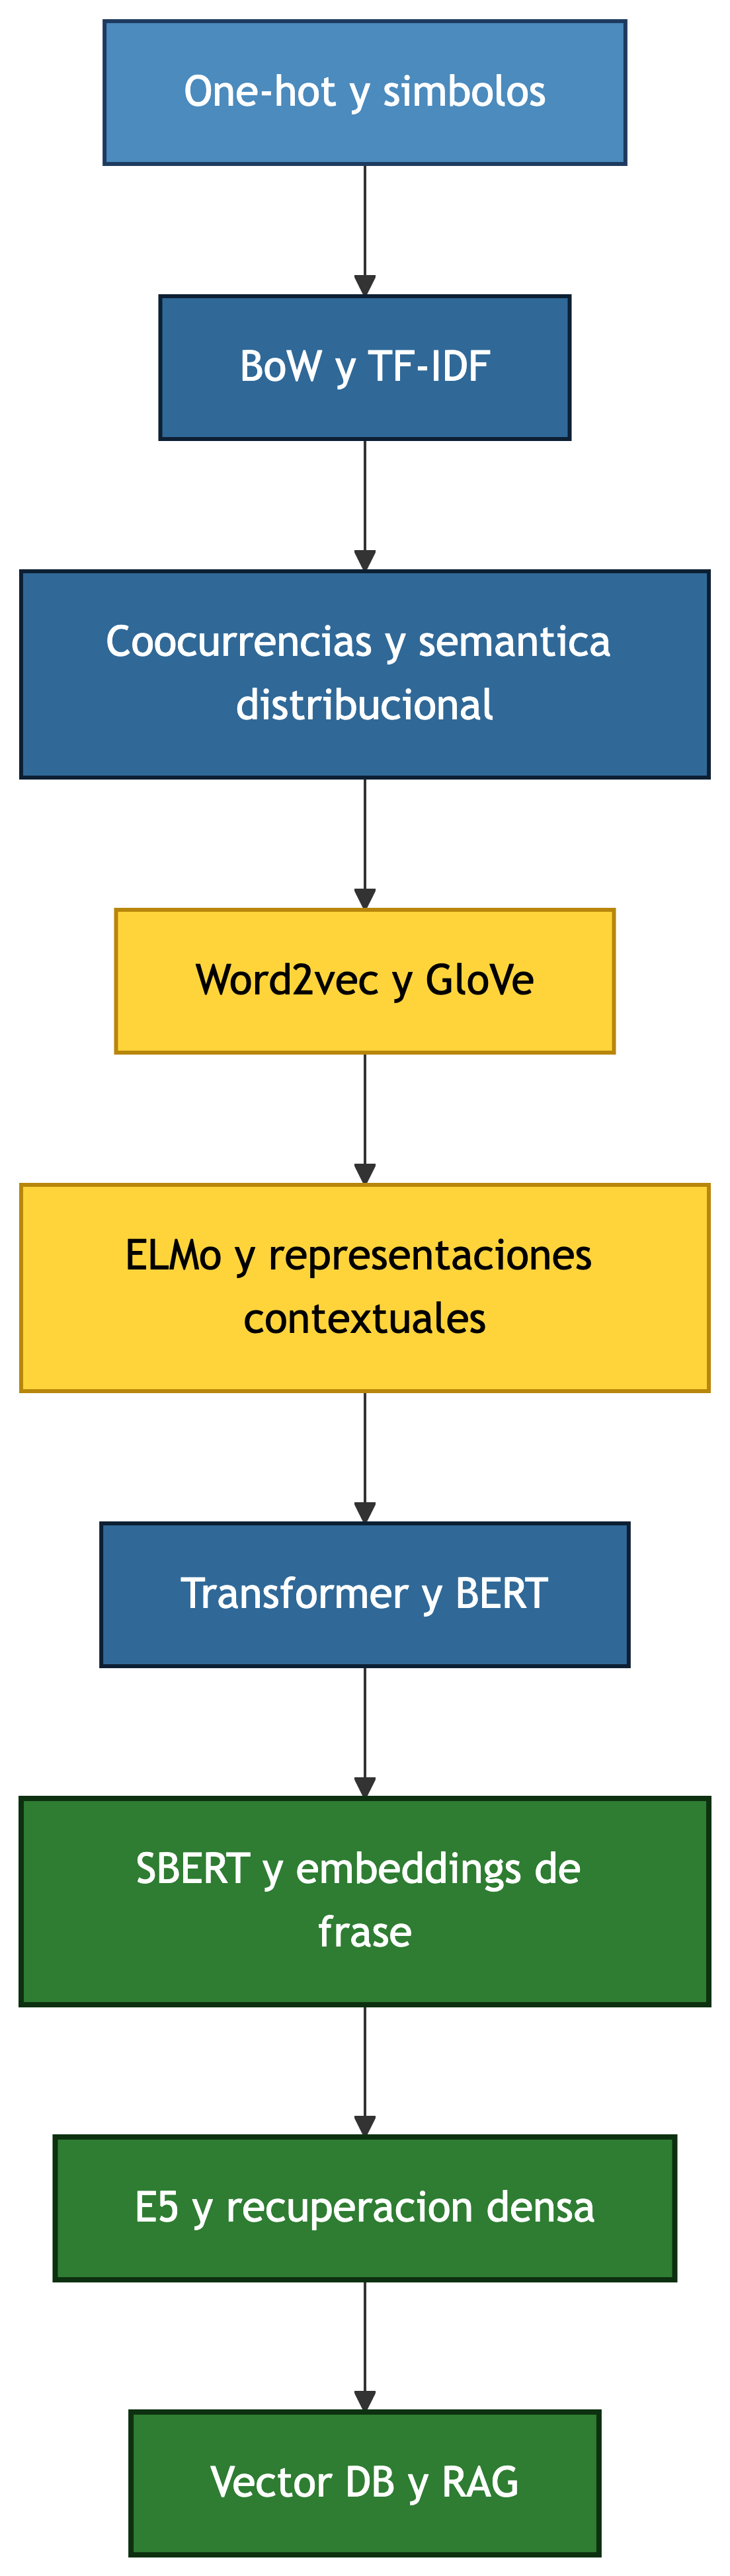
<figcaption>Figura 2</figcaption>
</figure>

<a href="#fig-linea-historica" class="quarto-xref">Figura 2</a> no
representa una sustitución total de una técnica por la siguiente. Las
representaciones dispersas siguen siendo útiles para interpretabilidad y
recuperación léxica; los embeddings densos pueden combinarse con índices
híbridos; y los LLMs modernos continúan utilizando tablas de embeddings
de tokens internamente.

## Qué ocurre dentro de un LLM actual

El recorrido de un LLM decoder-only puede resumirse así:

``` text
texto -> tokens -> IDs -> embeddings de token
      -> capas Transformer -> estados ocultos
      -> LM head -> logits -> siguiente token
```

Los embeddings de token son una pieza interna del modelo generativo,
pero no son idénticos a los embeddings de frases que se usan para
búsqueda semántica. Un modelo generativo puede producir buenos textos y
no ser el mejor modelo para recuperar documentos. Del mismo modo, un
modelo de embeddings puede ser excelente para similitud y no estar
diseñado para generar respuestas.

La página [01e - Del estado oculto a la salida](01e-llm-por-dentro.qmd)
amplía la relación entre backbone, estados ocultos y cabezas de salida.
La página [01b - LLMs e inferencia](01b-llms.qmd) explica la
tokenización y la predicción del siguiente token.

## Demostración: coincidencia literal frente a similitud semántica

La siguiente demostración utiliza únicamente TF-IDF para hacer visible
el problema de la coincidencia léxica. La frase sobre el felino y la
frase sobre el gato hablan de una situación similar, pero no comparten
exactamente todas sus palabras.

Vocabulario aprendido por TF-IDF:
['al', 'alfombra', 'alza', 'bolsa', 'cerro', 'descansa', 'duerme', 'el', 'en', 'europea', 'felino', 'gato', 'la', 'moqueta', 'sobre', 'un']

Matriz de similitud TF-IDF:
[[1.    0.065 0.065]
 [0.065 1.    0.065]
 [0.065 0.065 1.   ]]

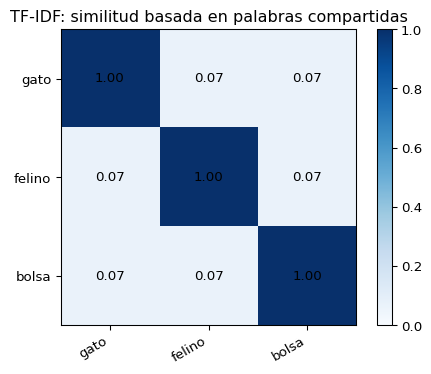

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

frases = [
    "El gato duerme sobre la alfombra.",
    "Un felino descansa en la moqueta.",
    "La bolsa europea cerro al alza.",
]

vectorizer = TfidfVectorizer(lowercase=True, strip_accents="unicode")
X = vectorizer.fit_transform(frases)
similitud_tfidf = cosine_similarity(X)

print("Vocabulario aprendido por TF-IDF:")
print(sorted(vectorizer.vocabulary_))
print("\nMatriz de similitud TF-IDF:")
print(np.round(similitud_tfidf, 3))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(similitud_tfidf, cmap="Blues", vmin=0, vmax=1)
ax.set_title("TF-IDF: similitud basada en palabras compartidas")
ax.set_xticks(range(len(frases)))
ax.set_yticks(range(len(frases)))
ax.set_xticklabels(["gato", "felino", "bolsa"], rotation=30, ha="right")
ax.set_yticklabels(["gato", "felino", "bolsa"])
for i in range(len(frases)):
    for j in range(len(frases)):
        ax.text(j, i, f"{similitud_tfidf[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
plt.close(fig)

En una segunda ejecución, puedes sustituir TF-IDF por un encoder de
frases. Para texto en español conviene utilizar un modelo multilingüe y
respetar el formato de consulta que indique su documentación:

In [2]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer("intfloat/multilingual-e5-small")

consultas = [
    "query: El gato duerme sobre la alfombra.",
    "query: Un felino descansa en la moqueta.",
    "query: La bolsa europea cerro al alza.",
]

embeddings = model.encode(consultas, normalize_embeddings=True)
similitud_embeddings = cosine_similarity(embeddings)
print(np.round(similitud_embeddings, 3))

La comparación no significa que los embeddings siempre sean mejores.
TF-IDF puede ser preferible cuando las coincidencias exactas son
importantes, cuando se necesita explicar por qué se recuperó un
documento o cuando el corpus tiene vocabulario muy específico. En
producción es frecuente combinar recuperación léxica y densa.

## La idea que conviene conservar

La evolución completa puede resumirse en cuatro preguntas:

| Pregunta | Respuesta histórica |
|------------------------------------|------------------------------------|
| ¿Cómo identifico símbolos? | One-hot y vocabularios |
| ¿Cómo cuento qué aparece en un documento? | Bag of Words y TF-IDF |
| ¿Cómo aprendo relaciones entre palabras? | Coocurrencias y embeddings estáticos |
| ¿Cómo incorporo contexto y comparo frases? | Transformers, SBERT y aprendizaje contrastivo |

En el resto del módulo, esta intuición se materializa en componentes
concretos:

``` text
representacion -> embedding de frase o documento
indexacion     -> Chroma, FAISS, HNSW o IVF
recuperacion   -> top-k y re-ranking
generacion     -> LLM condicionado por el contexto recuperado
orquestacion   -> cadenas, herramientas, MCP y agentes
evaluacion     -> recall, precision, faithfulness y RAGAS
```

La representación vectorial no es un detalle de implementación. Es la
decisión que determina qué significa que dos objetos sean parecidos y,
por tanto, qué información llegará a las etapas posteriores del sistema.

## Ruta hacia el Bloque 1

Continúa con:

1.  [01-fundamentos.qmd](01-fundamentos.qmd), para ver el mapa completo
    del bloque.
2.  [01a-transformer.qmd](01a-transformer.qmd), para entender la
    arquitectura que produce estados contextuales.
3.  [01b-llms.qmd](01b-llms.qmd), para estudiar tokenización,
    preentrenamiento e inferencia.
4.  [01c-embeddings.qmd](01c-embeddings.qmd), para profundizar en SBERT,
    E5 y la geometría semántica.
5.  [01d-vectordb.qmd](01d-vectordb.qmd), para convertir el espacio
    semántico en un sistema de búsqueda.

------------------------------------------------------------------------

## Referencias históricas

- Bengio et al. (2003)
- Firth (1957)
- Salton & Buckley (1988)
- Mikolov et al. (2013)
- Pennington et al. (2014)
- Peters et al. (2018)
- Vaswani et al. (2017)
- Devlin et al. (2019)
- Reimers & Gurevych (2019)
- Karpukhin et al. (2020)
- Lewis et al. (2020)
- Wang et al. (2022)

# References

Bengio, Y., Ducharme, R., Vincent, P., & Jauvin, C. (2003). A Neural
Probabilistic Language Model. *Journal of Machine Learning Research*,
*3*, 1137-1155. <https://www.jmlr.org/papers/v3/bengio03a.html>

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT:
Pre-training of Deep Bidirectional Transformers for Language
Understanding. *Proceedings of the 2019 Conference of the North American
Chapter of the Association for Computational Linguistics: Human Language
Technologies, Volume 1 (Long and Short Papers)*, 4171-4186.
<https://doi.org/10.18653/v1/N19-1423>

Firth, J. R. (1957). *A Synopsis of Linguistic Theory, 1930–1955*.
Studies in Linguistic Analysis (Special Volume of the Philological
Society).

Karpukhin, V., Oguz, B., Min, S., Lewis, P., Wu, L., Edunov, S., Chen,
D., & Yih, W. (2020). Dense Passage Retrieval for Open-Domain Question
Answering. *Proceedings of the 2020 Conference on Empirical Methods in
Natural Language Processing (EMNLP)*, 6769-6781.
<https://doi.org/10.18653/v1/2020.emnlp-main.550>

Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N.,
Küttler, H., Lewis, M., Yih, W., Rocktäschel, T., Riedel, S., & Kiela,
D. (2020). Retrieval-Augmented Generation for Knowledge-Intensive NLP
Tasks. *Advances in Neural Information Processing Systems*, *33*,
9459-9474. <https://arxiv.org/abs/2005.11401>

Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient
Estimation of Word Representations in Vector Space. *arXiv preprint
arXiv:1301.3781*. <https://arxiv.org/abs/1301.3781>

Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: Global
Vectors for Word Representation. *Proceedings of the 2014 Conference on
Empirical Methods in Natural Language Processing (EMNLP)*, 1532-1543.
<https://doi.org/10.3115/v1/D14-1162>

Peters, M. E., Neumann, M., Iyyer, M., Gardner, M., Clark, C., Lee, K.,
& Zettlemoyer, L. (2018). Deep Contextualized Word Representations.
*Proceedings of the 2018 Conference of the North American Chapter of the
Association for Computational Linguistics: Human Language Technologies,
Volume 1 (Long Papers)*, 2227-2237.
<https://doi.org/10.18653/v1/N18-1202>

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence Embeddings
using Siamese BERT-Networks. *Proceedings of the 2019 Conference on
Empirical Methods in Natural Language Processing and the 9th
International Joint Conference on Natural Language Processing
(EMNLP-IJCNLP)*, 3982-3992. <https://doi.org/10.18653/v1/D19-1410>

Salton, G., & Buckley, C. (1988). Term-weighting Approaches in Automatic
Text Retrieval. *Information Processing and Management*, *24*(5),
513-523. <https://doi.org/10.1016/0306-4573(88)90021-0>

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez,
A. N., Kaiser, L., & Polosukhin, I. (2017). *Attention is All You Need*.
*30*. <https://arxiv.org/abs/1706.03762>

Wang, L., Yang, N., Huang, X., Jiao, B., Yang, L., Jiang, D., Majumder,
R., & Wei, F. (2022). Text Embeddings by Weakly-Supervised Contrastive
Pre-training (E5). *arXiv preprint arXiv:2212.03533*.
<https://arxiv.org/abs/2212.03533>